# Test of the Reciever Simulator


In [1]:
from simulation.observation_handler import ObservationHandler
from simulation.loads import Load
from simulation.receiver import Receiver

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un

import os

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

In [2]:
test_receiver = Receiver(gamma_rec_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlockSDR0.s2p',
                         gains_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlock0.s2p')

test_receiver.change_freqs(np.linspace(60*un.MHz, 80*un.MHz, 1024))

open_load = Load(physical_temperature=273,
                 label='open',
                 termination_type='open',
                 freqs=test_receiver.freqs)

short_load = Load(physical_temperature=273,
                 label='short',
                 termination_type='short',
                 freqs=test_receiver.freqs)

long_open = Load(physical_temperature=273,
                 label='long_open',
                 termination_type='open',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

long_short = Load(physical_temperature=273,
                 label='long_short',
                 termination_type='short',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

matched_ambient = Load(physical_temperature=273,
                       label='internal_load',
                       termination_type='matched',
                       freqs=test_receiver.freqs)

heated_load = Load(physical_temperature=matched_ambient.t_src+40,
                      label='heated_load',
                      termination_type='matched',
                      freqs=test_receiver.freqs)


test_src = Load(physical_temperature=350,
                termination_impedence=75*un.Ohm,
                freqs=test_receiver.freqs,
                effective_cable_length=5*un.m,
                label='Test_src')


observation_handler_obj = ObservationHandler(observation_length=6*3600*un.s,
                                             receiver=test_receiver,
                                             sources=[long_open,
                                                      long_short,
                                                      open_load,
                                                      short_load,
                                                      test_src,
                                                      test_src,
                                                      test_src,
                                                      test_src],
                                            dicke_switch_sources=[matched_ambient,
                                                                  heated_load],
                                            dicke_switch_length=300*un.s,
                                            delta_t=10*un.s,
                                            n_t_unc_freq_coeffs=5,
                                            n_t_unc_time_coeffs=2,
                                            n_t_sin_freq_coeffs=3,
                                            n_t_sin_time_coeffs=3,
                                            n_t_cos_freq_coeffs=4,
                                            n_t_cos_time_coeffs=4)



Done


In [3]:
os.makedirs('simulated_data',
          exist_ok=True)

observation_handler_obj.save_to_hdf5(filepath="simulated_data/sim_data.hdf5")


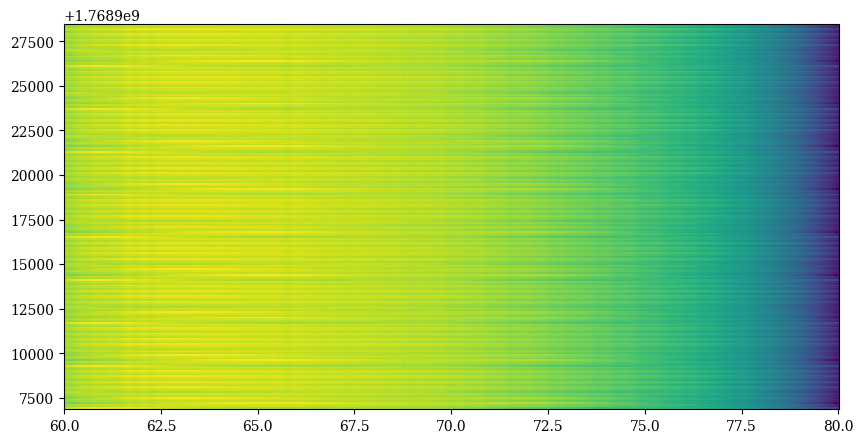

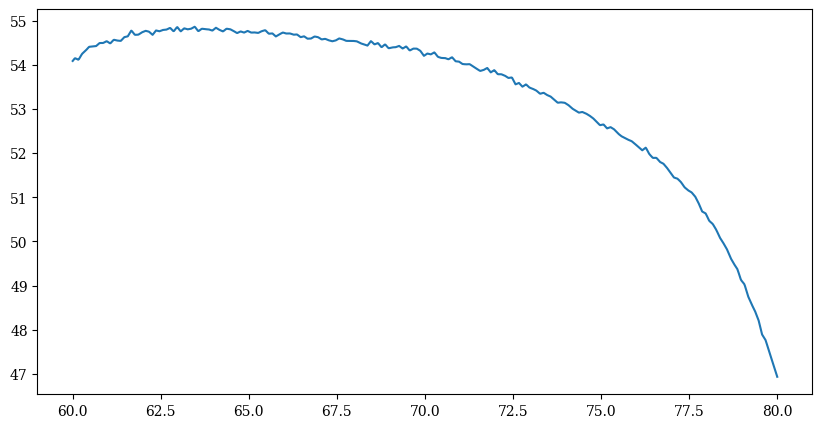

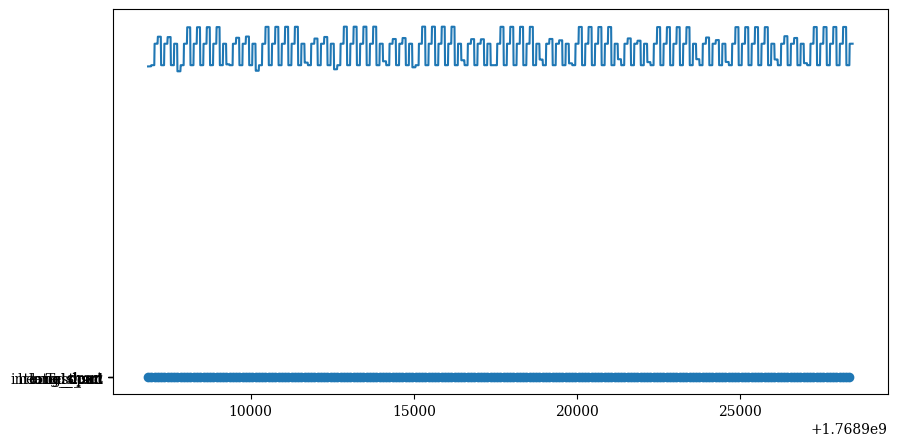

<class 'str'>
<class 'numpy.float64'>
internal_load
[272.92778792 272.98206135 273.05858243 ... 272.94714152 272.85558651
 273.09185771]
----
heated_load
[313.25492503 312.91046715 312.97866964 ... 313.03942695 312.81380779
 312.93599165]
----
long_open
[273.18864672 273.08809361 272.84956427 ... 273.01386757 272.87200622
 273.0033796 ]
----
long_short
[273.04752444 273.0524118  272.85870021 ... 272.87205612 272.92116584
 272.84358212]
----
open
[273.01431016 272.986134   273.23639912 ... 272.83549753 272.98089424
 272.93143475]
----
short
[273.001546   272.79990284 273.04721606 ... 273.01790595 272.99764187
 273.07917302]
----
Test_src
[349.93938415 350.00897769 349.96668467 ... 349.87966408 349.96443462
 350.05372301]
----


In [4]:

plt.pcolormesh(np.array(observation_handler_obj.freqs),
               np.array(observation_handler_obj.times),
               10*np.log10(observation_handler_obj.data))
plt.show()

plt.plot(observation_handler_obj.freqs,10*np.log10(np.mean(observation_handler_obj.data, axis=0)))
plt.show()

plt.plot(observation_handler_obj.times, observation_handler_obj.data.sum(axis=1))
plt.scatter(observation_handler_obj.switch_times, observation_handler_obj.switch_states)
plt.show()

print(type(observation_handler_obj.switch_states[0]))
print(type(observation_handler_obj.switch_times[0]))


for i, k in observation_handler_obj.temperature_dict.items():
    print(i)
    print(k)
    print('----')


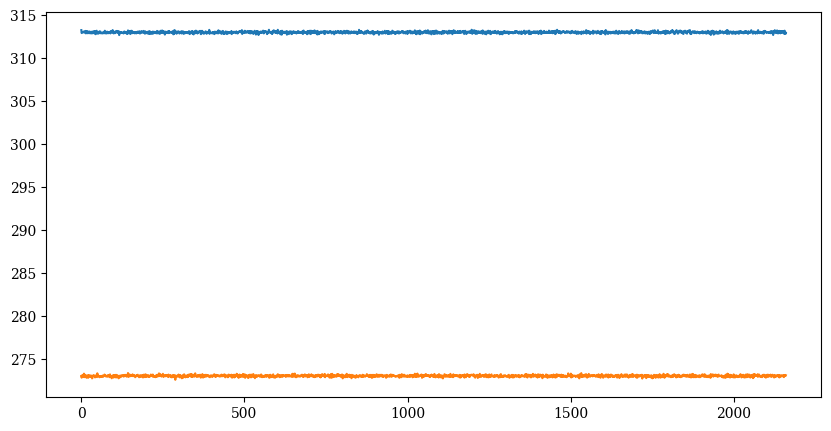

In [5]:
plt.plot(observation_handler_obj.temperature_dict['heated_load'])
plt.plot(observation_handler_obj.temperature_dict['short'])

In [6]:
from gcr.data_processing import create_nw_data_and_covariance_from_raw
from gcr.transfer_matrix_construction import construct_transfer_matrix


data_waterfall, covar_waterfall, final_times, final_states = create_nw_data_and_covariance_from_raw(waterfall=observation_handler_obj.data,
                                                                             times=observation_handler_obj.times,
                                                                             freqs=observation_handler_obj.freqs,
                                                                             switch_times=observation_handler_obj.switch_times,
                                                                             switch_states=observation_handler_obj.switch_states,
                                                                             source_temperatures=observation_handler_obj.temperature_dict,
                                                                             gamma_src_dict=observation_handler_obj.gamma_src_dict,
                                                                             noise_wave_loads=['open',
                                                                                               'short',
                                                                                               'long_open',
                                                                                               'long_short'],
                                                                            internal_load_label='internal_load',
                                                                            noise_source_label='heated_load',
                                                                            switch_buffer=2*un.s,
                                                                            gamma_rec=observation_handler_obj.gamma_rec)


In [7]:
print(final_states)

[np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short')]


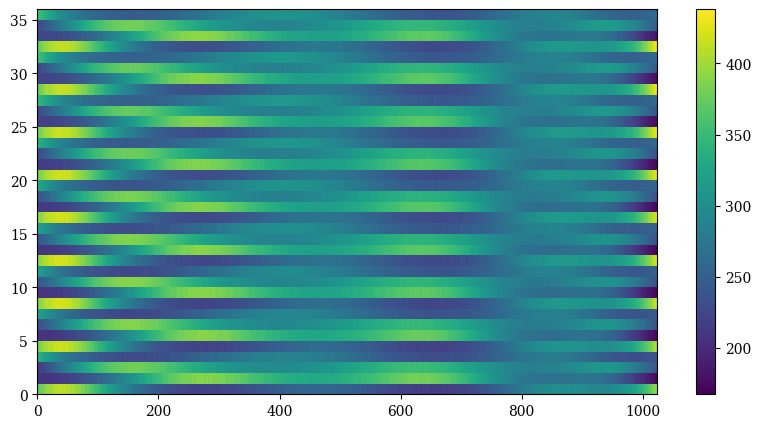

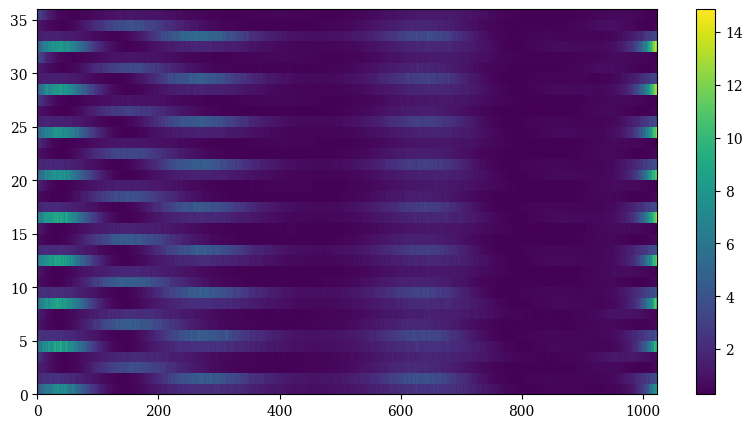

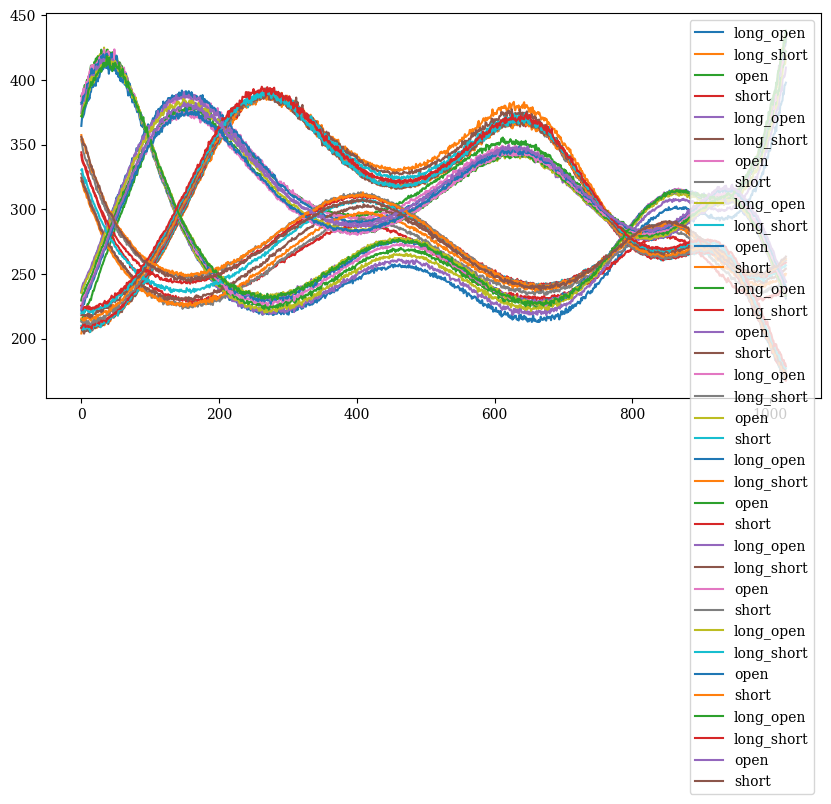

In [8]:
plt.pcolormesh(data_waterfall)
plt.colorbar()
plt.show()

plt.pcolormesh(covar_waterfall)
plt.colorbar()
plt.show()

for l, state in zip(data_waterfall, final_states):
    plt.plot(l, label=state)
plt.legend()
plt.show()



In [9]:
print(type(final_times[0]))

example_time = 100 *un.day

float_time = float(example_time.to(un.s) / un.s)

print(float_time)

<class 'float'>
8640000.0


In [10]:
unc_coeffs_deg = (5,5)
cos_coeffs_deg = (5,5)
sin_coeffs_deg = (5,5)

transfer_matrix, (freq_norm, time_norm) = construct_transfer_matrix(np.array(observation_handler_obj.freqs),
                                            np.array(final_times),
                                            switch_states_array=final_states,
                                            unc_poly_orders=unc_coeffs_deg,
                                            cos_poly_orders=cos_coeffs_deg,
                                            sin_poly_orders=sin_coeffs_deg,
                                            switch_state_src_gamma_dict=observation_handler_obj.gamma_src_dict,
                                            gamma_rec=observation_handler_obj.gamma_rec,
                                            return_norm_funcs=True)

print(freq_norm)


<function array_normalisation.<locals>.array_norm_func at 0x14fe15f80>


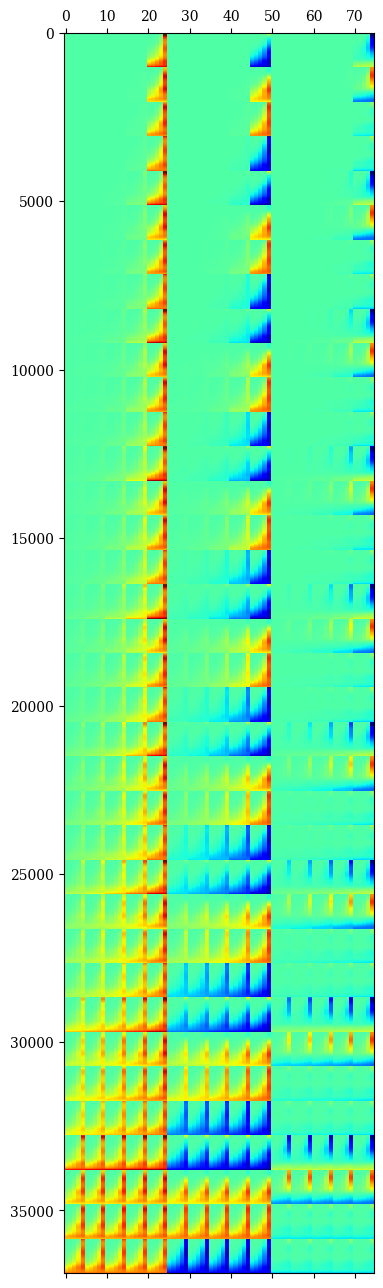

In [11]:
plt.matshow(transfer_matrix, aspect='auto', cmap='jet')
plt.show()

(36864,)
(36864, 75)
[-7.06099062e+01  1.41404368e+02 -1.16743894e+02  4.94648142e+01
 -8.22338039e+00  1.01032131e+02 -1.94732668e+02  1.61565635e+02
 -7.35608976e+01  1.39262569e+01 -2.86746476e+01  4.40077622e+01
 -3.73765948e+01  2.47544120e+01 -6.97349528e+00  5.40592490e+01
  9.05165087e+00 -6.34058768e+01  9.36726137e+00  1.10622077e+01
 -5.12908960e+01  1.23939809e+02 -7.97806079e+01  8.75138527e+00
  2.96832834e+02  1.65446806e+02 -3.35029758e+02  2.32009150e+02
 -6.38958933e+01  5.65244857e+00 -4.21475703e+02  1.40395458e+03
 -1.05634865e+03 -1.80811863e+02  2.26448853e+02  3.49418119e+02
 -9.64211841e+02  6.76401445e+01  1.06312820e+03 -4.44244150e+02
 -1.04998758e+02 -2.19900093e+02  9.95161757e+02 -9.48869835e+02
  2.21138352e+02  7.67995637e+00  9.69910914e+01 -1.80232376e+02
  1.07961904e+02  4.85951853e-01 -2.91541228e+01  8.97286061e+01
 -8.81118604e+00 -5.84002042e+01  1.33158512e+01  2.54608395e+02
 -4.96584827e+02  1.60506891e+02  9.86881296e+01 -2.46923491e+01
 -3.

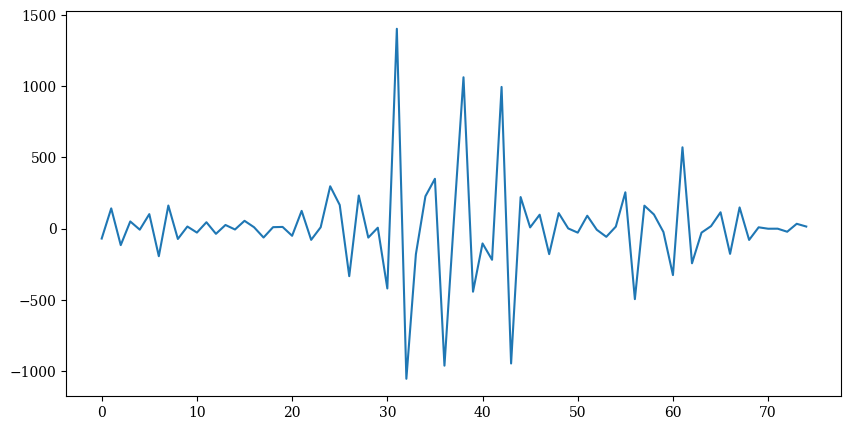

In [12]:
flattened_data = data_waterfall.flatten()

print(flattened_data.shape)
print(transfer_matrix.shape)

t_vec = np.linalg.lstsq(transfer_matrix, flattened_data)[0]


plt.plot(t_vec)


print(t_vec)

In [13]:
from gcr.basis_construction import reconstruct_surface

In [14]:
n_t_unc_coeffs = unc_coeffs_deg[0]*unc_coeffs_deg[-1]
n_t_cos_coeffs = cos_coeffs_deg[0]*cos_coeffs_deg[-1]
n_t_sin_coeffs = sin_coeffs_deg[0]*sin_coeffs_deg[-1]


t_unc_coeffs = t_vec[:n_t_unc_coeffs]
t_cos_coeffs = t_vec[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = t_vec[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)

[ -70.60990624  141.40436765 -116.74389361   49.46481418   -8.22338039
  101.03213066 -194.73266811  161.56563456  -73.5608976    13.92625695
  -28.67464764   44.00776217  -37.37659485   24.75441204   -6.97349528
   54.05924895    9.05165087  -63.40587678    9.36726137   11.06220769
  -51.29089604  123.9398092   -79.78060795    8.75138527  296.83283367]
[ 1.65446806e+02 -3.35029758e+02  2.32009150e+02 -6.38958933e+01
  5.65244857e+00 -4.21475703e+02  1.40395458e+03 -1.05634865e+03
 -1.80811863e+02  2.26448853e+02  3.49418119e+02 -9.64211841e+02
  6.76401445e+01  1.06312820e+03 -4.44244150e+02 -1.04998758e+02
 -2.19900093e+02  9.95161757e+02 -9.48869835e+02  2.21138352e+02
  7.67995637e+00  9.69910914e+01 -1.80232376e+02  1.07961904e+02
  4.85951853e-01]
[ -29.15412282   89.72860613   -8.81118604  -58.40020423   13.31585121
  254.60839498 -496.58482701  160.50689087   98.68812956  -24.6923491
 -327.33199817  570.77989944 -244.58411588  -29.09698545   16.64838842
  114.07126181 -178.3542

In [15]:

t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


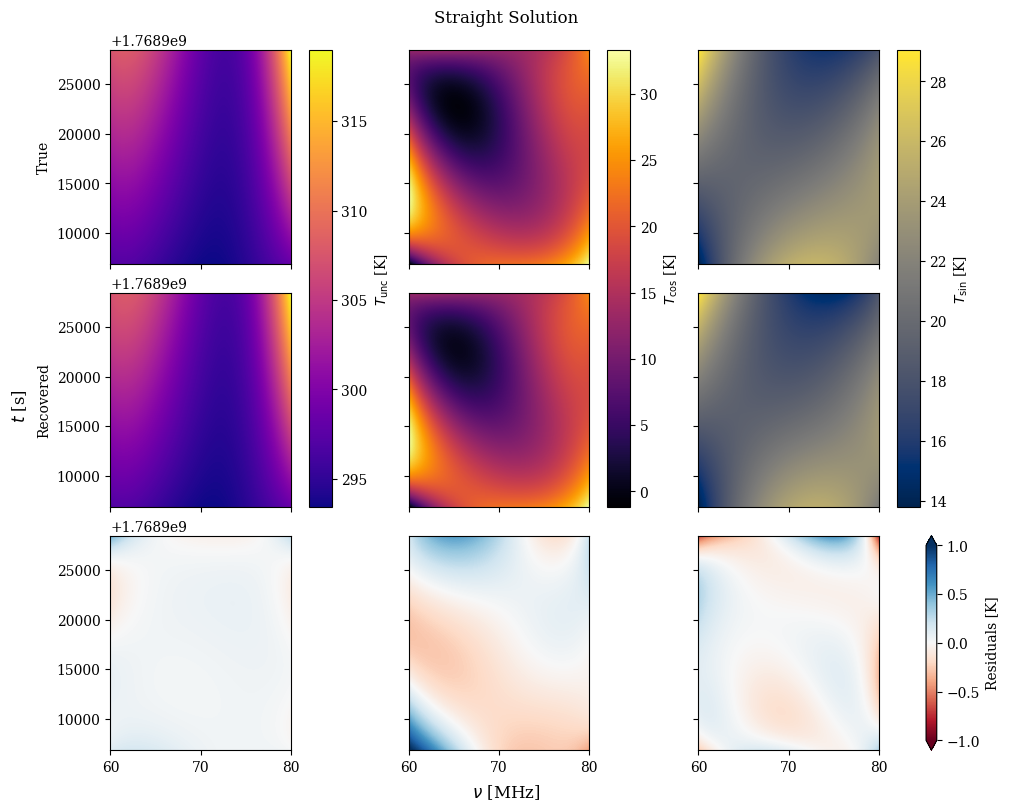

In [16]:
# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)

resid_vminmax = 1

unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Straight Solution')
plt.show()


In [17]:
flat_cov = covar_waterfall.flatten()
inv_cov = 1 / flat_cov

from gcr.noise_wave_gcr import construct_gcr_lhs, construct_gcr_rhs
from scipy.sparse.linalg import cg


S_cov = np.abs(t_vec) / 2
S_inv = np.zeros_like(t_vec)# 1/S_cov
S_inv = 1/S_cov #  np.zeros_like(t_vec)# 1/S_cov

lhs = construct_gcr_lhs(transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv)

rhs = construct_gcr_rhs(d=flattened_data,
                        H_matrix=transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv,
                        T_nw0=t_vec,
                        omega_d=np.random.normal(loc=0, scale=1, size=flattened_data.shape),
                        omega_t=np.random.normal(loc=0, scale=1, size=t_vec.shape))

gcr_wsol = cg(lhs, rhs, x0=t_vec)[0]


In [18]:
t_unc_coeffs = gcr_wsol[:n_t_unc_coeffs]
t_cos_coeffs = gcr_wsol[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = gcr_wsol[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)


t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


[ -70.60848144  141.40959788 -116.7411877    49.47031373   -8.2484662
  101.03698977 -194.72969929  161.57283724  -73.55591937   13.90535251
  -28.67382055   44.01368929  -37.37153055   24.76413285   -6.99624712
   54.05782406    9.05244034  -63.40351129    9.37654111   11.04505048
  -51.32673069  123.91356719  -79.80004519    8.75177257  296.86845234]
[ 1.65424771e+02 -3.35055887e+02  2.31987569e+02 -6.39105265e+01
  5.67655571e+00 -4.21498296e+02  1.40393461e+03 -1.05636880e+03
 -1.80820331e+02  2.26480099e+02  3.49402388e+02 -9.64229965e+02
  6.76289810e+01  1.06313042e+03 -4.44210908e+02 -1.05010753e+02
 -2.19910855e+02  9.95158472e+02 -9.48862781e+02  2.21166094e+02
  7.67973817e+00  9.69921050e+01 -1.80230244e+02  1.07975269e+02
  4.45495859e-01]
[ -29.1706345    89.71456977   -8.82829409  -58.41540971   13.31887782
  254.5934037  -496.60332225  160.49107722   98.67383735  -24.6920119
 -327.3515201   570.76244807 -244.60509501  -29.11717164   16.65106234
  114.05212446 -178.37782

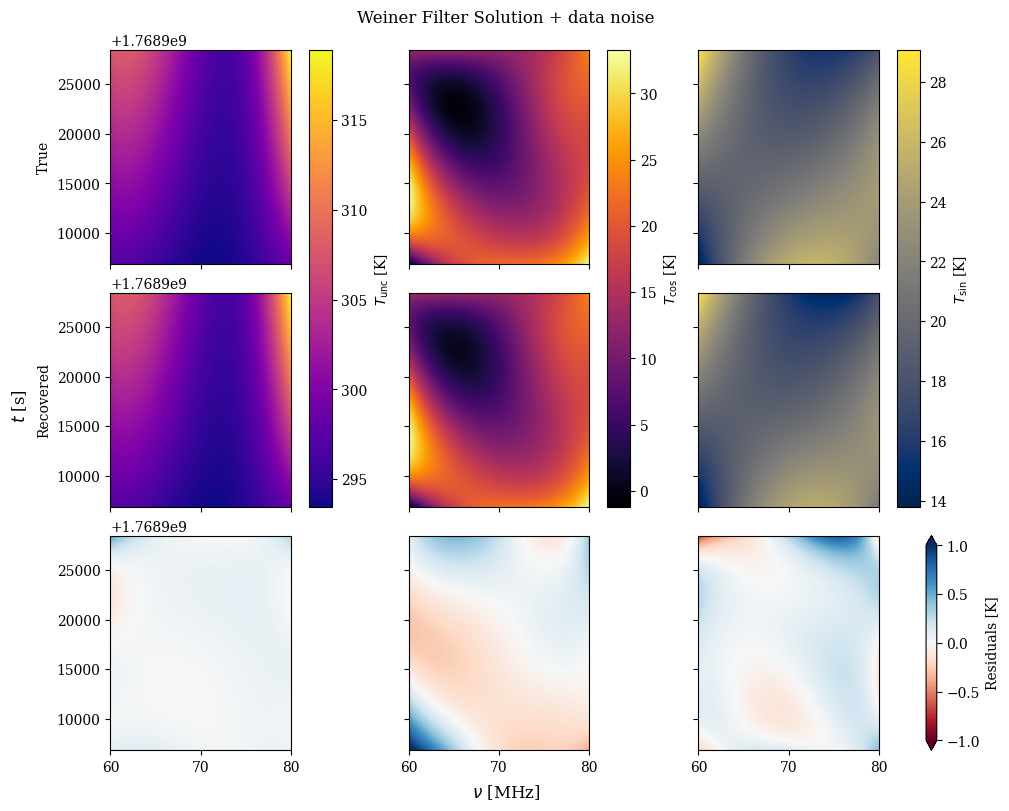

In [19]:

# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)


unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Weiner Filter Solution + data noise')
plt.show()


In [20]:
t_vec - gcr_wsol

array([-0.0014248 , -0.00523023, -0.00270591, -0.00549955,  0.02508581,
       -0.00485911, -0.00296883, -0.00720269, -0.00497822,  0.02090443,
       -0.00082709, -0.00592712, -0.0050643 , -0.00972081,  0.02275185,
        0.00142489, -0.00078947, -0.00236549, -0.00927974,  0.0171572 ,
        0.03583465,  0.02624201,  0.01943724, -0.0003873 , -0.03561868,
        0.02203533,  0.02612836,  0.02158151,  0.01463316, -0.02410715,
        0.02259333,  0.01996826,  0.02014733,  0.0084674 , -0.03124602,
        0.01573144,  0.01812369,  0.01116351, -0.00222308, -0.03324207,
        0.01199451,  0.01076239,  0.00328495, -0.00705398, -0.02774155,
        0.0002182 , -0.00101362, -0.00213219, -0.01336566,  0.04045599,
        0.01651168,  0.01403636,  0.01710804,  0.01520548, -0.00302661,
        0.01499128,  0.01849524,  0.01581364,  0.0142922 , -0.00033719,
        0.01952193,  0.01745137,  0.02097913,  0.02018619, -0.00267393,
        0.01913735,  0.02354552,  0.02221768,  0.02545845, -0.00

In [21]:
from MomentRFI.MomentRFI import load_waterfall, validate_waterfall, IterativeSurfaceFitter
from MomentRFI.MomentRFI.plotting import plot_summary